## ℹ️ Sobre este Notebook

Este notebook foca em **seleção de features e otimização de modelos** de trading. Inclui análise de importância de features, ajuste de rácios risco/retorno, e simulação avançada com stop-loss, filtros de confiança e dimensionamento dinâmico de posições.


# Crypto EMA Fast Movement Prediction with PySpark
This notebook demonstrates how to predict whether the trend_ema_fast (EMA fast) will go up or down for the next 5-minute candle using PySpark MLlib with logistic regression and Random Forest. We'll use a 1.22 GB dataset of 5-minute candles with technical indicators, add lagged close prices, and lagged trend_ema_fast features to improve performance. We'll perform feature selection based on importance, adjust the risk-reward ratio, and backtest the Random Forest model to simulate trades, including transaction fees, a stop-loss threshold, confidence-based trade filtering, dynamic position sizing, and visualize the cumulative profit.

In [19]:
# Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, lead, lag, lit, sum as pyspark_sum
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window
import uuid
import matplotlib.pyplot as plt

In [20]:
# remove warnings
import warnings
warnings.filterwarnings("ignore")

In [21]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName('FeatureSelection') \
    .master('local[*]') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print(f'Spark {spark.version}')


In [22]:
# (removed Windows-specific PySpark env var configuration)
# bigdata conda environment sets these automatically


In [23]:
# Load the 1.22 GB CSV dataset
data_path = "./../data/btc_04h_usdt_binance.parquet"
df = spark.read.parquet(data_path)

# Show first few rows
df.show(5)

# Print schema to understand data types
df.printSchema()

+---+--------------------+-------+-------+-------+-------+-----------+--------------------+----------------+------+--------------+----------------+------+-------+------------------+------------------+----------+---------+-------------------+-------------+-------------------+-----------+----------+------------------+--------------+--------------+--------------+--------------+--------------+---------------+---------------+--------------+------------------+-----------------+--------------+------------------+---------------+---------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+----------+-----------------+---------------+--------------+--------------+--------------+--------------+--------------------+--------------------+---------------------+----------+----------------+---------+---------+-------------+--------------+-------------------+-------------------+----------------+------------------+---------+---------+------------

In [24]:
# Define feature columns (technical indicators and other metrics)
all_features = [
    'open', 'high', 'low', 'volume', 'quote_vol', 'trades', 'taker_buy_base', 
    'taker_buy_quote', 'volume_adi', 'volume_obv', 'volume_cmf', 'volume_fi', 
    'volume_em', 'volume_sma_em', 'volume_vpt', 'volume_vwap', 'volume_mfi', 
    'volume_nvi', 'volatility_bbm', 'volatility_bbh', 'volatility_bbl', 
    'volatility_bbw', 'volatility_bbp', 'volatility_bbhi', 'volatility_bbli', 
    'volatility_kcc', 'volatility_kch', 'volatility_kcl', 'volatility_kcw', 
    'volatility_kcp', 'volatility_kchi', 'volatility_kcli', 'volatility_dcl', 
    'volatility_dch', 'volatility_dcm', 'volatility_dcw', 'volatility_dcp', 
    'volatility_atr', 'volatility_ui', 'trend_macd', 'trend_macd_signal', 
    'trend_macd_diff', 'trend_sma_fast', 'trend_sma_slow', 'trend_ema_fast', 
    'trend_ema_slow', 'trend_vortex_ind_pos', 'trend_vortex_ind_neg', 
    'trend_vortex_ind_diff', 'trend_trix', 'trend_mass_index', 'trend_dpo', 
    'trend_kst', 'trend_kst_sig', 'trend_kst_diff', 'trend_ichimoku_conv', 
    'trend_ichimoku_base', 'trend_ichimoku_a', 'trend_ichimoku_b', 'trend_stc', 
    'trend_adx', 'trend_adx_pos', 'trend_adx_neg', 'trend_cci', 
    'trend_visual_ichimoku_a', 'trend_visual_ichimoku_b', 'trend_aroon_up', 
    'trend_aroon_down', 'trend_aroon_ind', 'momentum_rsi', 'momentum_stoch_rsi', 
    'momentum_stoch_rsi_k', 'momentum_stoch_rsi_d', 'momentum_tsi', 
    'momentum_uo', 'momentum_stoch', 'momentum_stoch_signal', 'momentum_wr', 
    'momentum_ao', 'momentum_roc', 'momentum_ppo', 'momentum_ppo_signal', 
    'momentum_ppo_hist', 'momentum_kama', 'others_dr', 'others_dlr', 'others_cr', 
    'morningstar', 'hammer', 'piercing', '3soldiers', 'engulfing', 'sma200', 
    'sma50', 'ema200', 'ema50', 'slope', 'slope_obv', 'slope_rsi'
]

In [25]:
# Create lagged features for the previous 5 candles' close prices and trend_ema_fast
window_spec = Window.orderBy("open_time")

# Add lagged close prices (lag 1 to 5)
for i in range(1, 6):
    lag_col_name = f"close_lag_{i}"
    df = df.withColumn(lag_col_name, lag(col("close").cast("double"), i).over(window_spec))
    all_features.append(lag_col_name)

# Add lagged trend_ema_fast values (lag 1 to 5)
for i in range(1, 6):
    lag_col_name = f"ema_fast_lag_{i}"
    df = df.withColumn(lag_col_name, lag(col("trend_ema_fast").cast("double"), i).over(window_spec))
    all_features.append(lag_col_name)

# Create target variable: 1 if next candle's trend_ema_fast > current trend_ema_fast, else 0
df = df.withColumn("next_ema_fast", lead(col("trend_ema_fast").cast("double"), 1).over(window_spec))
df = df.withColumn("label", when(col("next_ema_fast") > col("trend_ema_fast"), 1).otherwise(0))

# Drop rows with null values in features or label
df = df.dropna(subset=all_features + ["label"])

# Cast features to double for ML
for feature in all_features:
    df = df.withColumn(feature, col(feature).cast("double"))

# Show sample of processed data
df.select("trend_ema_fast", "ema_fast_lag_1", "ema_fast_lag_2", "next_ema_fast", "label").show(5)

+------------------+------------------+------------------+------------------+-----+
|    trend_ema_fast|    ema_fast_lag_1|    ema_fast_lag_2|     next_ema_fast|label|
+------------------+------------------+------------------+------------------+-----+
|10689.594891260198|10539.521235125689| 10371.34691423945|10807.195677220168|    1|
|10807.195677220168|10689.594891260198|10539.521235125689|10793.239419186297|    0|
|10793.239419186297|10807.195677220168|10689.594891260198|10657.356431619171|    0|
|10657.356431619171|10793.239419186297|10807.195677220168|10444.169288293146|    0|
|10444.169288293146|10657.356431619171|10793.239419186297|10256.912474709585|    0|
+------------------+------------------+------------------+------------------+-----+
only showing top 5 rows



In [26]:
# Split data into training (80%) and test (20%) sets
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

# Cache datasets for faster processing
train_df.cache()
test_df.cache()

# Print dataset sizes
print(f"Training set size: {train_df.count()} rows")
print(f"Test set size: {test_df.count()} rows")

Training set size: 1804 rows
Test set size: 389 rows


In [27]:
# Create feature vector
assembler = VectorAssembler(inputCols=all_features, outputCol="features")

# Scale features to normalize data
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", 
                       withStd=True, withMean=True)

In [28]:
# Initialize models
# Logistic Regression
lr = LogisticRegression(featuresCol="scaled_features", labelCol="label", 
                       maxIter=100, regParam=0.1)

# Random Forest
rf = RandomForestClassifier(
    featuresCol="scaled_features", 
    labelCol="label", 
    numTrees=100, 
    maxDepth=10, 
    seed=42,
    probabilityCol="probability"  # Explicitly specify the probability column
)

In [29]:
# Create pipelines for both models
lr_pipeline = Pipeline(stages=[assembler, scaler, lr])
rf_pipeline = Pipeline(stages=[assembler, scaler, rf])

# Train models
print("Training Logistic Regression...")
lr_model = lr_pipeline.fit(train_df)

print("Training Random Forest...")
rf_model = rf_pipeline.fit(train_df)

Training Logistic Regression...
Training Random Forest...


In [30]:
# Make predictions on test set
lr_predictions = lr_model.transform(test_df)
rf_predictions = rf_model.transform(test_df)

# Show sample predictions
lr_predictions.select("label", "prediction", "probability").show(5)
rf_predictions.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       1.0|[0.40692592774585...|
|    1|       1.0|[0.16917500833377...|
|    0|       0.0|[0.70391684213711...|
|    1|       0.0|[0.81619259624739...|
|    1|       1.0|[0.04361894119037...|
+-----+----------+--------------------+
only showing top 5 rows

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       1.0|[0.22734118203402...|
|    1|       1.0|[0.16631387009895...|
|    0|       0.0|[0.72571931611137...|
|    1|       0.0|[0.89421766263787...|
|    1|       1.0|[0.06261212996356...|
+-----+----------+--------------------+
only showing top 5 rows



In [31]:
# Evaluate models using Area Under ROC Curve (AUC) and Confusion Matrix
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql.functions import col

# AUC Evaluator
evaluator_roc = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")

# Multi-class evaluator for precision, recall, and F1-score
evaluator_multi = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction")

# Evaluate Logistic Regression
lr_auc = evaluator_roc.evaluate(lr_predictions)
lr_precision = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "weightedPrecision"})
lr_recall = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "weightedRecall"})
lr_f1 = evaluator_multi.evaluate(lr_predictions, {evaluator_multi.metricName: "f1"})

# Evaluate Random Forest
rf_auc = evaluator_roc.evaluate(rf_predictions)
rf_precision = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedPrecision"})
rf_recall = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedRecall"})
rf_f1 = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "f1"})

# Compute Confusion Matrix for Logistic Regression
lr_confusion = lr_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
print("Logistic Regression Confusion Matrix:")
lr_confusion.show()

# Compute Confusion Matrix for Random Forest
rf_confusion = rf_predictions.groupBy("label", "prediction").count().orderBy("label", "prediction")
print("Random Forest Confusion Matrix:")
rf_confusion.show()

# Print evaluation results
print(f"Logistic Regression AUC: {lr_auc:.4f}")
print(f"Logistic Regression Precision: {lr_precision:.4f}")
print(f"Logistic Regression Recall: {lr_recall:.4f}")
print(f"Logistic Regression F1-Score: {lr_f1:.4f}")
print(f"Random Forest AUC: {rf_auc:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")

Logistic Regression Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  149|
|    0|       1.0|   31|
|    1|       0.0|   35|
|    1|       1.0|  174|
+-----+----------+-----+

Random Forest Confusion Matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|  151|
|    0|       1.0|   29|
|    1|       0.0|   34|
|    1|       1.0|  175|
+-----+----------+-----+

Logistic Regression AUC: 0.9180
Logistic Regression Precision: 0.8307
Logistic Regression Recall: 0.8303
Logistic Regression F1-Score: 0.8304
Random Forest AUC: 0.9139
Random Forest Precision: 0.8386
Random Forest Recall: 0.8380
Random Forest F1-Score: 0.8382


In [32]:
# Feature Importance Analysis for Random Forest
rf_stage = rf_model.stages[-1]  # Get the RandomForestClassifier stage from the pipeline
importances = rf_stage.featureImportances
feature_importance = [(feature, importance) for feature, importance in zip(all_features, importances)]
feature_importance.sort(key=lambda x: x[1], reverse=True)
print("Top 10 Most Important Features:")
for feature, importance in feature_importance[:10]:
    print(f"{feature}: {importance:.4f}")

# Select features with importance >= 0.01
importance_threshold = 0.01
selected_features = [feature for feature, importance in feature_importance if importance >= importance_threshold]
print(f"\nNumber of features before selection: {len(all_features)}")
print(f"Number of features after selection: {len(selected_features)}")
print("Selected Features:")
print(selected_features)

Top 10 Most Important Features:
volatility_kcp: 0.0993
volume_fi: 0.0733
volatility_bbp: 0.0606
momentum_wr: 0.0574
momentum_rsi: 0.0473
trend_cci: 0.0458
momentum_stoch: 0.0437
volatility_dcp: 0.0390
momentum_roc: 0.0361
trend_vortex_ind_pos: 0.0283

Number of features before selection: 109
Number of features after selection: 20
Selected Features:
['volatility_kcp', 'volume_fi', 'volatility_bbp', 'momentum_wr', 'momentum_rsi', 'trend_cci', 'momentum_stoch', 'volatility_dcp', 'momentum_roc', 'trend_vortex_ind_pos', 'volume_sma_em', 'trend_vortex_ind_neg', 'trend_adx_pos', 'trend_adx_neg', 'volume_vpt', 'trend_aroon_up', 'momentum_uo', 'momentum_stoch_signal', 'trend_stc', 'volume_mfi']


In [33]:
# Retrain the Random Forest model with selected features
# Create new feature vector with selected features
assembler_selected = VectorAssembler(inputCols=selected_features, outputCol="features")

# Scale features to normalize data
scaler_selected = StandardScaler(inputCol="features", outputCol="scaled_features", 
                                withStd=True, withMean=True)

# Random Forest with selected features
rf_selected = RandomForestClassifier(
    featuresCol="scaled_features", 
    labelCol="label", 
    numTrees=100, 
    maxDepth=10, 
    seed=42,
    probabilityCol="probability"
)

# Create pipeline with selected features
rf_pipeline_selected = Pipeline(stages=[assembler_selected, scaler_selected, rf_selected])

# Train the model with selected features
print("Training Random Forest with Selected Features...")
rf_model_selected = rf_pipeline_selected.fit(train_df)

# Make predictions with the new model
rf_predictions = rf_model_selected.transform(test_df)

# Evaluate the new Random Forest model
rf_auc_selected = evaluator_roc.evaluate(rf_predictions)
rf_precision_selected = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedPrecision"})
rf_recall_selected = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "weightedRecall"})
rf_f1_selected = evaluator_multi.evaluate(rf_predictions, {evaluator_multi.metricName: "f1"})

# Print evaluation results for the new model
print("Random Forest (Selected Features) Evaluation:")
print(f"AUC: {rf_auc_selected:.4f}")
print(f"Precision: {rf_precision_selected:.4f}")
print(f"Recall: {rf_recall_selected:.4f}")
print(f"F1-Score: {rf_f1_selected:.4f}")

Training Random Forest with Selected Features...
Random Forest (Selected Features) Evaluation:
AUC: 0.9136
Precision: 0.8355
Recall: 0.8355
F1-Score: 0.8355


In [34]:
from pyspark.ml.linalg import DenseVector

def extract_probability(probability_struct, prediction):
    if probability_struct is None:
        return 0.5  # Default to 0.5 if probability is missing
    # Extract the values array from the struct
    prob_values = probability_struct["values"]
    # Convert DenseVector to a Python list if necessary
    if isinstance(prob_values, DenseVector):
        prob_values = prob_values.toArray().tolist()
    # Ensure prediction is an integer
    pred_index = int(prediction)
    # Return the probability corresponding to the predicted class
    return float(prob_values[pred_index])

Schema of rf_predictions:
root
 |-- _c0: string (nullable = true)
 |-- open_time: string (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: string (nullable = true)
 |-- volume: double (nullable = true)
 |-- close_time: string (nullable = true)
 |-- quote_vol: double (nullable = true)
 |-- trades: double (nullable = true)
 |-- taker_buy_base: double (nullable = true)
 |-- taker_buy_quote: double (nullable = true)
 |-- ignore: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- volume_adi: double (nullable = true)
 |-- volume_obv: double (nullable = true)
 |-- volume_cmf: double (nullable = true)
 |-- volume_fi: double (nullable = true)
 |-- volume_em: double (nullable = true)
 |-- volume_sma_em: double (nullable = true)
 |-- volume_vpt: double (nullable = true)
 |-- volume_vwap: double (nullable = true)
 |-- volume_mfi: double (nullable = true)
 |-- volume_nvi: double (nullable = true)

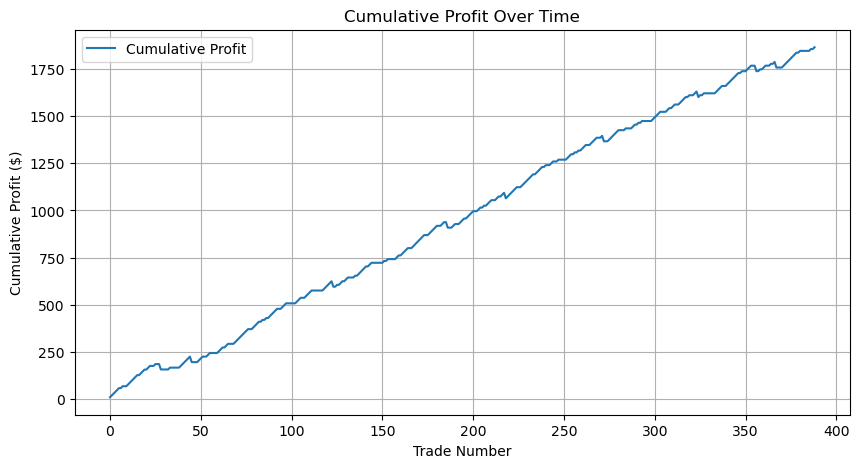

In [35]:
# Backtest the Random Forest model (with selected features) on the test dataset
from pyspark.sql.functions import col, when, lag, lead, lit, sum as pyspark_sum, udf
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
from pyspark.ml.linalg import DenseVector

# Define backtest parameters with adjusted risk-reward ratio
take_profit_threshold = 0.002  # Adjusted to 0.2% for 2:1 risk-reward ratio
stop_loss_threshold = -0.002   # Keep at -0.3% (so TP:SL = 2:1)
initial_balance = 10000.0      # Starting balance in USD
base_position_size = 0.95      # Base position size (95% of balance)
transaction_fee = 0.001        # 0.1% fee per trade
confidence_threshold = 0.8     # Only trade if prediction probability exceeds 80%

# Repartition the DataFrame by symbol to improve window operation performance
rf_predictions = rf_predictions.repartition("symbol")

# Add columns to track trade outcomes
# Partition by symbol to compute cumulative profit separately for each symbol
window_spec = Window.partitionBy("symbol").orderBy("open_time").rowsBetween(Window.unboundedPreceding, 0)

# Debug: Inspect the probability column before applying the UDF
print("Schema of rf_predictions:")
rf_predictions.printSchema()
print("Sample values of probability column:")
rf_predictions.select("probability").show(5, truncate=False)

# Define a UDF to extract the probability for the predicted class
def extract_probability(probability_vector, prediction):
    if probability_vector is None:
        return 0.5  # Default to 0.5 if probability is missing
    try:
        # Convert DenseVector to a Python list
        prob_values = probability_vector.toArray().tolist()
        # Ensure prediction is an integer
        pred_index = int(prediction)
        # Validate the index
        if pred_index < 0 or pred_index >= len(prob_values):
            raise ValueError(f"Invalid prediction index {pred_index} for prob_values {prob_values}")
        # Return the probability corresponding to the predicted class
        return float(prob_values[pred_index])
    except Exception as e:
        print(f"Error in extract_probability: {str(e)}")
        return 0.5

extract_probability_udf = udf(extract_probability, DoubleType())

# Extract prediction probability for the predicted class
rf_predictions = rf_predictions.withColumn(
    "pred_probability",
    extract_probability_udf(col("probability"), col("prediction"))
)

# Filter trades based on prediction confidence
rf_predictions = rf_predictions.withColumn(
    "trade_action",
    when(col("pred_probability") >= confidence_threshold,
         when(col("prediction") == 1, "buy").otherwise("sell")
    ).otherwise("no_trade")
)

# Calculate dynamic position size based on prediction probability
# Scale position size between 0.05 (at confidence_threshold=0.8) and 0.1 (at pred_probability=1.0)
rf_predictions = rf_predictions.withColumn(
    "position_size",
    when(col("pred_probability") >= confidence_threshold,
         base_position_size + (col("pred_probability") - confidence_threshold) * (0.99 - base_position_size) / (1.0 - confidence_threshold)
    ).otherwise(0.0)
)

# Calculate the percentage change in trend_ema_fast
rf_predictions = rf_predictions.withColumn(
    "ema_fast_change",
    (col("next_ema_fast") - col("trend_ema_fast")) / col("trend_ema_fast")
)

# Determine trade outcome with adjusted thresholds
rf_predictions = rf_predictions.withColumn(
    "trade_outcome",
    when(
        (col("trade_action") == "buy") & (col("ema_fast_change") >= take_profit_threshold),
        "profit"
    ).when(
        (col("trade_action") == "buy") & (col("ema_fast_change") <= stop_loss_threshold),
        "loss"
    ).when(
        (col("trade_action") == "sell") & (col("ema_fast_change") <= -take_profit_threshold),
        "profit"
    ).when(
        (col("trade_action") == "sell") & (col("ema_fast_change") >= -stop_loss_threshold),
        "loss"
    ).otherwise("no_trade")
)

# Calculate profit/loss for each trade, including transaction fees, using dynamic position size
rf_predictions = rf_predictions.withColumn(
    "trade_profit",
    when(col("trade_outcome") == "profit", 
         initial_balance * col("position_size") * take_profit_threshold - initial_balance * col("position_size") * transaction_fee)
    .when(col("trade_outcome") == "loss", 
          initial_balance * col("position_size") * stop_loss_threshold - initial_balance * col("position_size") * transaction_fee)
    .otherwise(0.0)
)

# Compute cumulative profit/loss using sum over the window
rf_predictions = rf_predictions.withColumn(
    "cumulative_profit",
    pyspark_sum(col("trade_profit")).over(window_spec)
)

# Show sample of backtest results, including position_size
print("Sample Backtest Results:")
rf_predictions.select(
    "open_time", "trend_ema_fast", "next_ema_fast", "prediction", "pred_probability",
    "position_size", "trade_action", "ema_fast_change", "trade_outcome", "trade_profit", "cumulative_profit"
).show(4)

# Compute backtest summary
total_trades = rf_predictions.filter(col("trade_outcome").isin("profit", "loss")).count()
winning_trades = rf_predictions.filter(col("trade_outcome") == "profit").count()
final_balance = initial_balance + rf_predictions.select("trade_profit").agg({"trade_profit": "sum"}).collect()[0][0]

# Print backtest summary
print("Backtest Summary:")
print(f"Total Trades: {total_trades}")
print(f"Winning Trades: {winning_trades}")
print(f"Win Rate: {winning_trades / total_trades:.4f}" if total_trades > 0 else "Win Rate: N/A")
print(f"Final Balance: ${final_balance:.2f}")
print(f"Total Profit/Loss: ${final_balance - initial_balance:.2f}")

# Visualize cumulative profit over time
profits = rf_predictions.select("cumulative_profit").collect()
profits_list = [row["cumulative_profit"] for row in profits]
plt.figure(figsize=(10, 5))
plt.plot(profits_list, label="Cumulative Profit")
plt.title("Cumulative Profit Over Time")
plt.xlabel("Trade Number")
plt.ylabel("Cumulative Profit ($)")
plt.grid(True)
plt.legend()
plt.show()

In [36]:
# Save models for future use
#lr_model.save(f"lr_model_{uuid.uuid4()}")
#rf_model.save(f"rf_model_{uuid.uuid4()}")
#rf_model_selected.save(f"rf_model_selected_{uuid.uuid4()}")

# Stop Spark session to free resources
spark.stop()